In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.metrics import r2_score as R2
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as r2
from copy import deepcopy
import utils
from unet import UNet_nobatchnorm
from scipy.stats import pearsonr
#JU's addtion to automate inputs and outputs
import helper_functions as hf
import os
from data_loading import load_data_from_nc, degrade_space_gaussian, degrade_time_uniform #HW: degrade_space_gaussian should not have been imported here. It would be replaced by the funciton defined in a later block.
from scipy.signal import convolve2d, convolve


def save_fn(var_input_list, var_output_list):
    var_input_join  = '_and_'.join(var_input_list)
    var_output_join = '_and_'.join(var_output_list)
    return '{}_to_{}'.format(var_input_join, var_output_join)

torch.cuda.set_device(1)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print ('Running on ', device)

Running on  cuda:1


In [2]:
print(torch.__version__)
print(torch.version.cuda)

2.5.1
12.6


In [3]:
maxEpochs =  300 #small number is taken for debugging
nensemble = 10 #How many training sessions are run for each configuration 
Nbase = 16

In [4]:
!nvidia-smi #GPU usage should be maxed out during training; tune batch_size according to that

Sat Feb 21 14:21:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   54C    P0            275W /  400W |   32087MiB /  40960MiB |     82%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
root_dir = '/work/uo0780/u241359/project_tide_synergy/data/'
nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)


Ntrain = np.sum([nc.dimensions['time_counter'].size for nc in nctrains], axis = 0)
Ntest = np.sum([nc.dimensions['time_counter'].size for nc in nctest], axis = 0)

print('number of training records:', Ntrain)
print('number of testing records:', Ntest)

numTrainFiles = len(nctrains)
numRecsFile = nctrains[0].dimensions['time_counter'].size #How many snapshots in time in each data set there is
print (numRecsFile)

# Modify the loadtrain function to pull data from preloaded memory
def loaddata_preloaded_train(index, batch_size, all_input_data, all_output_data):
    rec_slice = slice(index, index + batch_size)
    lim = 720
    width = 256
    yslice = slice(0, lim)
    xslice = slice(0, width)
    # print('rec_slice is:')
    # print(rec_slice)
    # print('mean of squared values of loaded input data:')
    # print("{0:0.32f}".format(np.nanmean(all_input_data[rec_slice, :, yslice, xslice]**2)))
    return (all_input_data[rec_slice, :, yslice, xslice], 
            all_output_data[rec_slice, :, yslice, xslice])
#Load test data as one single batch
def loaddata_preloaded_test(all_input_data, all_output_data):
    #rec_slice = slice(index, index + batch_size)
    lim = 720
    width = 256
    yslice = slice(0, lim)
    xslice = slice(0, width)
    # print('rec_slice is:')
    # print(rec_slice)
    # print('mean of squared values of loaded input data:')
    # print("{0:0.32f}".format(np.nanmean(all_input_data[rec_slice, :, yslice, xslice]**2)))
    return (all_input_data[:, :, yslice, xslice], 
            all_output_data[:, :, yslice, xslice])


number of training records: 600
number of testing records: 150
150


In [6]:
#Functions for low-pass filtering
def gaussian_kernel(decaylength): 
    """Generates a Gaussian kernel."""
    #decaylength is in the unit of grid resolution (4km in Aurelien's data.) So in physical units, the decay lenght would be decaylength*(4 km).
    size=int(2*decaylength)
    sigma=decaylength/(2*np.sqrt(2*np.log(2))) #Interpretting decaylength as the FWHM of Gaussian
    kernel = np.fromfunction(
        lambda x, y: (1 / np.sqrt(2 * np.pi * sigma ** 2)) * 
                      np.exp(-((x- size/2)**2 + (y-size/2)**2) / (2 * sigma ** 2)),
        (size, size)  
    ) #Creating a kernel with 
    return kernel / np.sum(kernel)  # Normalize the kernel
    
def degrade_space_gaussian(field, decaylength):
    nt, nx, ny = np.shape(field)
    kernel = gaussian_kernel(decaylength)
    filtered_field = np.empty([nt, nx, ny])

    for i in range(nt):
        filtered_field[i, : ,:] = convolve2d(field[i, : ,:], kernel, mode = 'same', boundary='symm')#,  fillvalue = np.average(field[i, : ,:]))
    return filtered_field

# Load all data into memory; no normalization is done here yet.
# Apply a spatial lowpass filter to U,V  
# decayunits is how many units of grid spacing is the decay length scale. A grid spacing is 4km in Aurelien's data. So in physical units, the decay lenght would be decayunits*(4 km).
def preload_data_filterUV(nctrains, total_records,decayunits=25,plot=True):
    #total_records = Ntrain#sum(nc.dimensions['time_counter'].size for nc in nctrains)
    #dimensions of data of the nc file.
    max_height = 722
    max_width = 258
    all_input_data = np.zeros((total_records, N_inp, max_height, max_width))*np.nan
    all_output_data = np.zeros((total_records, N_out, max_height, max_width))*np.nan
    current_index = 0
    for ncindex, ncdata in enumerate(nctrains):
        num_recs = ncdata.dimensions['time_counter'].size
        rec_slice = slice(current_index, current_index + num_recs)
        
        for ind, var_name in enumerate(var_input_names):
            data_slice = np.squeeze(ncdata.variables[var_name])
            # print('data_slice shape:')
            # print(data_slice.shape)        
            #Turns out to be (time, height, width)
            # print('var_name:')
            # print(var_name)
            # Apply lowpass filter when the field is 'T_xy_ins'
            if var_name in ("u_xy_ins", "v_xy_ins"):
                if plot == True:
                    #Plot an image before the filter
                    itime=20        
                    cmapmax=np.max(data_slice[itime,:,:])
                    cmapmin=np.min(data_slice[itime,:,:])
                    figT, axT = plt.subplots(1, 2, figsize=(5, 5))
                    figT.set_dpi(256)   
                    im0=axT[0].pcolor(data_slice[itime,:,:],vmin=cmapmin,vmax=cmapmax)
                    axT[0].set_aspect(1)
                #Lowpass filter
                data_slice=degrade_space_gaussian(data_slice,decayunits)
                if plot == True:
                    axT[1].pcolor(data_slice[itime,:,:],vmin=cmapmin,vmax=cmapmax)
                    axT[1].set_aspect(1)
                    cbar0=plt.colorbar(im0, ax=axT, fraction=0.046, pad=0.04)
            
            #For some variables, the dimensions in (x, y) may be smaller than (max_height, max_width). Changing the code so that it adapts them.
            # Get the actual dimensions of data_slice
            slice_height, slice_width = data_slice.shape[-2], data_slice.shape[-1]
            # Place data_slice into the corresponding slice of all_input_data
            all_input_data[rec_slice, ind, :slice_height, :slice_width] = data_slice
    

        for ind, var_name in enumerate(var_output_names):
            data_slice = np.squeeze(ncdata.variables[var_name])
            # if var_name == 'T_xy_ins':
            #     if plot == True:
            #         #Plot an image before the filter
            #         itime=20        
            #         cmapmax=np.max(data_slice[itime,:,:])
            #         cmapmin=np.min(data_slice[itime,:,:])
            #         figT, axT = plt.subplots(1, 2, figsize=(5, 5))
            #         figT.set_dpi(256)   
            #         im0=axT[0].pcolor(data_slice[itime,:,:],vmin=cmapmin,vmax=cmapmax)
            #         axT[0].set_aspect(1)
            #     #Lowpass filter
            #     data_slice=degrade_space_gaussian(data_slice,decayunits)
            #     if plot == True:
            #         axT[1].pcolor(data_slice[itime,:,:],vmin=cmapmin,vmax=cmapmax)
            #         axT[1].set_aspect(1)
            #         cbar0=plt.colorbar(im0, ax=axT, fraction=0.046, pad=0.04)
            #all_output_data[rec_slice, ind, :, :] = data_slice
            # Get the actual dimensions of data_slice
            slice_height, slice_width = data_slice.shape[-2], data_slice.shape[-1]
            # Place data_slice into the corresponding slice of all_input_data
            all_output_data[rec_slice, ind, :slice_height, :slice_width] = data_slice

        current_index += num_recs
        
    return all_input_data, all_output_data


In [7]:
def run_model(var_input_names, var_output_names, save_fn_prefix, N_inp, N_out, iensemble, R2_all, corr_all):
    def totorch(x):
        return torch.tensor(x, dtype = torch.float).cuda()

    model = UNet_nobatchnorm(N_inp, N_out, bilinear = True, Nbase = Nbase).cuda()
    #model = torch.compile(UNet(N_inp, N_out, bilinear = True, Nbase = Nbase).cuda())

    if iensemble == 0:
        input = torch.randn(1,N_inp,256,720).to(device) 
        output = model(input)
        print('Model has ', utils.nparams(model)/1e6, ' million params')

    # for index in range(0, Ntrain, batch_size):
    #     inp, out = loadtrain_preloaded(index, batch_size, all_train_input, all_train_output)
    #     print(inp.shape, out.shape)
#         print(np.nanmean(inp**2), np.max(inp**2), inp.shape)
#         print(np.nanmean(out**2), np.max(out**2), inp.shape)

    inp_test, out_test = loaddata_preloaded_test(all_test_input, all_test_output)
    #inp, out_test = loadtest()
    # print('shapes of input and output TEST data:')
    # print(inp_test.shape, out_test.shape)
    with torch.no_grad():
        inp_test = totorch(inp_test)

    Tcycle = 10
    criterion_train  = nn.L1Loss()
    optim = torch.optim.AdamW(model.parameters(), lr=lr0, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-5*100) #increase weight_decay ***

    r2_test = np.zeros(maxEpochs)
    epochmin = []
    maxr2l = []

    learn = np.zeros(maxEpochs)
    minloss = 1000
    maxR2 = -1000
    minlosscount = 0
    perm = False

    model_best = deepcopy(model)  # Initialize before the loop for safety

    #print('Starting training loop')
    for epoch in tqdm(range(maxEpochs)):
        lr = utils.cosineSGDR(optim, epoch, T0=Tcycle, eta_min=0, eta_max=lr0, scheme = 'constant')  #captioning this seems to make the printed corr larger??***
        model.train()
        index_perm = np.arange(0, Ntrain, batch_size)
        
        if perm:
            index_perm = np.random.permutation(index_perm)
        
        for index in index_perm:
            inp, out = loaddata_preloaded_train(index, batch_size, all_train_input, all_train_output)            
#           inp, out = loadtrain(index, batch_size, nctrains)
            inp, out = totorch(inp), totorch(out)
            #continue #do this to pause the later operations to check how long it takes for the steps up to this 
            out_mod = model(inp)
            loss = criterion_train(out.squeeze(), out_mod.squeeze())
            #Set gradient to zero
            optim.zero_grad()
            #Compute gradients       
            loss.backward()
            #Update parameters with new gradient
            optim.step()
            #Record train loss
            #scheduler.step()
          
        model.eval()
        with torch.no_grad():
            #model_cpu = model.to('cpu')
            #out_mod = model_cpu(inp_test.to('cpu'))
            out_mod=model(inp_test)
            
            r2 = R2(out_test.flatten(), (out_mod).cpu().numpy().flatten())
            r2_test[epoch] = r2
            #print('Debugging: R2 of current epoch:', r2)#Debugging
            #record current best model and best predictions
            if maxR2 <  r2:
                maxR2 = r2
                epochmin.append(epoch)
                maxr2l.append(maxR2)                
                model_best = deepcopy(model)
                corr, pval = pearsonr(out_test.flatten(), (out_mod).cpu().numpy().flatten())
                print('R2:', r2, ' corr: ', corr, ' pval: ', pval)
            #model = model_cpu.to(device)

    #_, out_test = loadtest()
    model_best.eval()
    with torch.no_grad():
    #     inp_test = totorch(inp)
        model_best.to('cpu') #added by HW 
        out_mod = model_best(inp_test.to('cpu')).detach().cpu().numpy()

    print('training finished')
    
    R2_all[iensemble]=R2(out_test.flatten(), out_mod.flatten())
    corr_all[iensemble]=pearsonr(out_test.flatten(), out_mod.flatten())[0]
    # print('Best model R2:', R2_all[iensemble])#pearsonr(out_test.flatten(), out_mod.flatten())[0])
    # print('Best model corr:', corr_all[iensemble])#R2(out_test.flatten(), out_mod.flatten()))
    print('start saving')
    # Nx, Ny = out_test.shape[2:]; Nx, Ny
    # print(out_mod.shape, 'outout model shape')
    dr = '/work/uo0780/u241359/project_tide_synergy/trainedmodels' #'./models/to_vel'
    os.makedirs(dr, exist_ok=True) # exist_ok=True allows the function to do nothing (i.e., not raise an error) if the directory already exists.
    fstr = f'{save_fn_prefix}_rp_{iensemble}' 
    PATH = dr + f'/{fstr}.pth'
    torch.save(model_best.state_dict(), PATH)
    print('model saved')

In [ ]:
decayunits=5 #Try 5 and 25 

vi1 = 'ssh_ins'
vi2 = 'u_xy_ins'
vi3 = 'v_xy_ins'

vo1 = 'ssh_cos'
vo2 = 'ssh_sin'


batch_size = 60 #maximizing it so that the GPU memory maxes out. Needs to be divisible by Ntrain. Otherwise there will be size mismatch issues.
lr0 = 0.005*10/batch_size #Roughly should scale inversely to batch_size


var_input_names = [vi1, vi2, vi3]
var_output_names = [vo1, vo2]
N_inp = len(var_input_names)
N_out = len(var_output_names)

save_fn_prefix  = 'any_{}{}{}_{}{}_nobatchnorm_degradeUV_du_{}'.format(vi1, vi2, vi3, vo1, vo2, decayunits)
nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

all_train_input, all_train_output = preload_data_filterUV(nctrains, Ntrain, decayunits=decayunits,plot=False)
all_test_input, all_test_output = preload_data_filterUV(nctest, Ntest, decayunits=decayunits,plot=False)

#Normalize data
#Compute mean and variance for normalization
mean_input=np.nanmean(np.concatenate((all_train_input, all_test_input), axis=0),axis=(0, 2, 3))
mean_output=np.nanmean(np.concatenate((all_train_output, all_test_output), axis=0),axis=(0, 2, 3))
#Subtract the data with their means
all_train_input=all_train_input-mean_input[None, :, None, None]
all_train_output=all_train_output-mean_output[None, :, None, None]
all_test_input=all_test_input-mean_input[None, :, None, None]
all_test_output=all_test_output-mean_output[None, :, None, None]
#Compute the variances
var_input=np.nanmean((np.concatenate((all_train_input, all_test_input), axis=0))**2,axis=(0, 2, 3))
var_output=np.nanmean((np.concatenate((all_train_output, all_test_output), axis=0))**2,axis=(0, 2, 3))
print("mean and variance of all input data, after lowpass is applied:")
print(mean_input,var_input)
print("mean and variance of all output data, after lowpass is applied:")
print(mean_output,var_output)

#Scale the data so that they have variance of 1
all_train_input=all_train_input/np.sqrt(var_input[None, :, None, None])
all_train_output=all_train_output/np.sqrt(var_output[None, :, None, None])
all_test_input=all_test_input/np.sqrt(var_input[None, :, None, None])
all_test_output=all_test_output/np.sqrt(var_output[None, :, None, None])
#Have checked that after these operations, the data is scaled to be zero mean and variance 1.


#Recording performance metrics on test data after eaching training cycle
R2_all = np.zeros(nensemble)
corr_all = np.zeros(nensemble)
for iensemble in np.arange(nensemble):
    run_model(var_input_names, var_output_names, save_fn_prefix, N_inp, N_out, iensemble, R2_all, corr_all)  
print('R2 from the best models in each run are:')
print(R2_all)
print('corr from the best models in each run are:')
print(corr_all)



mean and variance of all input data, after lowpass is applied:
[ 0.03307104  0.03565131 -0.00191466] [0.3119807  0.04311782 0.04500816]
mean and variance of all output data, after lowpass is applied:
[-5.16228102e-04 -9.83592627e-05] [9.36516511e-05 1.01456128e-04]
Model has  1.124706  million params


  0%|          | 1/300 [00:07<39:42,  7.97s/it]

R2: 0.0023636198023518906  corr:  0.09538193252992756  pval:  0.0


  1%|          | 2/300 [00:15<37:39,  7.58s/it]

R2: 0.08915703818085585  corr:  0.35761690486125564  pval:  0.0


...

 47%|████▋     | 140/300 [15:28<19:07,  7.17s/it]

R2: 0.9327343566770152  corr:  0.9658966278026034  pval:  0.0


 50%|████▉     | 149/300 [16:23<16:55,  6.73s/it]

R2: 0.9349073172396221  corr:  0.9670651038971567  pval:  0.0


 50%|█████     | 150/300 [16:32<18:14,  7.30s/it]

In [9]:
all_test_input.shape

(150, 3, 722, 258)

In [10]:
def preload_data(nctrains, total_records):
    #total_records = Ntrain#sum(nc.dimensions['time_counter'].size for nc in nctrains)
    #dimensions of data of the nc file.
    max_height = 722
    max_width = 258
    all_input_data = np.zeros((total_records, N_inp, max_height, max_width))*np.nan
    all_output_data = np.zeros((total_records, N_out, max_height, max_width))*np.nan
    current_index = 0
    for ncindex, ncdata in enumerate(nctrains):
        num_recs = ncdata.dimensions['time_counter'].size
        rec_slice = slice(current_index, current_index + num_recs)
        
        for ind, var_name in enumerate(var_input_names):
            data_slice = np.squeeze(ncdata.variables[var_name])
            # print('data_slice shape:')
            # print(data_slice.shape)        
            #all_input_data[rec_slice, ind, :, :] = data_slice
            #For some variables, the dimensions in (x, y) may be smaller than (max_height, max_width). Changing the code so that it adapts them.
            # Get the actual dimensions of data_slice
            slice_height, slice_width = data_slice.shape[-2], data_slice.shape[-1]
            # Place data_slice into the corresponding slice of all_input_data
            all_input_data[rec_slice, ind, :slice_height, :slice_width] = data_slice
    

        for ind, var_name in enumerate(var_output_names):
            data_slice = np.squeeze(ncdata.variables[var_name])
            #all_output_data[rec_slice, ind, :, :] = data_slice
            # Get the actual dimensions of data_slice
            slice_height, slice_width = data_slice.shape[-2], data_slice.shape[-1]
            # Place data_slice into the corresponding slice of all_input_data
            all_output_data[rec_slice, ind, :slice_height, :slice_width] = data_slice

        current_index += num_recs
        
    return all_input_data, all_output_data

# # Modify the loadtrain function to pull data from preloa
all_test_input_raw, all_test_output_raw = preload_data(nctest, Ntest)
all_test_input_raw.shape

(150, 3, 722, 258)

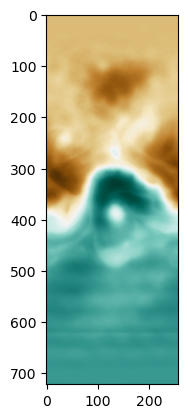

In [11]:
plt.imshow(all_test_input[100,0,::-1,:],cmap='BrBG')

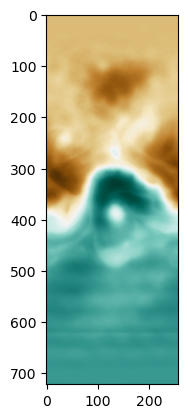

In [12]:
plt.imshow(all_test_input_raw[100,0,::-1,:],cmap='BrBG')

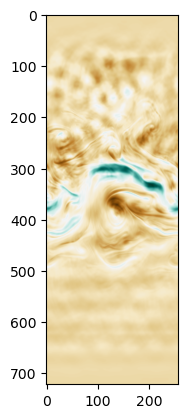

In [13]:
plt.imshow(all_test_input_raw[100,1,::-1,:],cmap='BrBG')

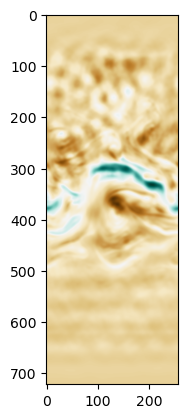

In [14]:
plt.imshow(all_test_input[100,1,::-1,:],cmap='BrBG')

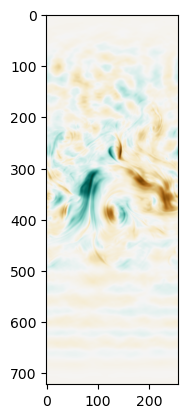

In [15]:
plt.imshow(all_test_input_raw[100,2,::-1,:],cmap='BrBG')

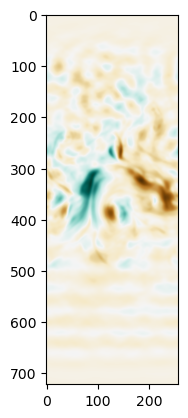

In [16]:
plt.imshow(all_test_input[100,2,::-1,:],cmap='BrBG')

In [ ]:
decayunits=5 #Try 5 and 25 

vi1 = 'T_xy_ins'
vi2 = 'u_xy_ins'
vi3 = 'v_xy_ins'

vo1 = 'ssh_cos'
vo2 = 'ssh_sin'


batch_size = 60 #maximizing it so that the GPU memory maxes out. Needs to be divisible by Ntrain. Otherwise there will be size mismatch issues.
lr0 = 0.005*10/batch_size #Roughly should scale inversely to batch_size


var_input_names = [vi1, vi2, vi3]
var_output_names = [vo1, vo2]
N_inp = len(var_input_names)
N_out = len(var_output_names)

save_fn_prefix  = 'any_{}{}{}_{}{}_nobatchnorm_degradeUV_du_{}'.format(vi1, vi2, vi3, vo1, vo2, decayunits)
nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

all_train_input, all_train_output = preload_data_filterUV(nctrains, Ntrain, decayunits=decayunits,plot=False)
all_test_input, all_test_output = preload_data_filterUV(nctest, Ntest, decayunits=decayunits,plot=False)

#Normalize data
#Compute mean and variance for normalization
mean_input=np.nanmean(np.concatenate((all_train_input, all_test_input), axis=0),axis=(0, 2, 3))
mean_output=np.nanmean(np.concatenate((all_train_output, all_test_output), axis=0),axis=(0, 2, 3))
#Subtract the data with their means
all_train_input=all_train_input-mean_input[None, :, None, None]
all_train_output=all_train_output-mean_output[None, :, None, None]
all_test_input=all_test_input-mean_input[None, :, None, None]
all_test_output=all_test_output-mean_output[None, :, None, None]
#Compute the variances
var_input=np.nanmean((np.concatenate((all_train_input, all_test_input), axis=0))**2,axis=(0, 2, 3))
var_output=np.nanmean((np.concatenate((all_train_output, all_test_output), axis=0))**2,axis=(0, 2, 3))
print("mean and variance of all input data, after lowpass is applied:")
print(mean_input,var_input)
print("mean and variance of all output data, after lowpass is applied:")
print(mean_output,var_output)

#Scale the data so that they have variance of 1
all_train_input=all_train_input/np.sqrt(var_input[None, :, None, None])
all_train_output=all_train_output/np.sqrt(var_output[None, :, None, None])
all_test_input=all_test_input/np.sqrt(var_input[None, :, None, None])
all_test_output=all_test_output/np.sqrt(var_output[None, :, None, None])
#Have checked that after these operations, the data is scaled to be zero mean and variance 1.


#Recording performance metrics on test data after eaching training cycle
R2_all = np.zeros(nensemble)
corr_all = np.zeros(nensemble)
for iensemble in np.arange(nensemble):
    run_model(var_input_names, var_output_names, save_fn_prefix, N_inp, N_out, iensemble, R2_all, corr_all)  
print('R2 from the best models in each run are:')
print(R2_all)
print('corr from the best models in each run are:')
print(corr_all)




mean and variance of all input data, after lowpass is applied:
[ 2.51429352e+01  3.56513101e-02 -1.91466116e-03] [0.34119618 0.04311782 0.04500816]
mean and variance of all output data, after lowpass is applied:
[-5.16228102e-04 -9.83592627e-05] [9.36516511e-05 1.01456128e-04]
Model has  1.124706  million params


  0%|          | 1/300 [00:07<37:28,  7.52s/it]

R2: -0.004908866554550029  corr:  0.14899271863854135  pval:  0.0


  1%|          | 2/300 [00:14<36:58,  7.44s/it]

R2: 0.07294151204542088  corr:  0.2868640086239769  pval:  0.0


...

 73%|███████▎  | 220/300 [22:37<08:15,  6.20s/it]

R2: 0.9040106993481549  corr:  0.9508204813075191  pval:  0.0


 80%|████████  | 240/300 [24:31<06:20,  6.33s/it]

R2: 0.9040778243635083  corr:  0.950867431549456  pval:  0.0


 82%|████████▏ | 245/300 [24:59<05:11,  5.67s/it]

In [8]:
#Just adding one more re-run (changing iensemble to be 9. Igonre the first 9 elements of R2_all)
decayunits=5 #Try 5 and 25 

vi1 = 'T_xy_ins'
vi2 = 'u_xy_ins'
vi3 = 'v_xy_ins'

vo1 = 'ssh_cos'
vo2 = 'ssh_sin'


batch_size = 60 #maximizing it so that the GPU memory maxes out. Needs to be divisible by Ntrain. Otherwise there will be size mismatch issues.
lr0 = 0.005*10/batch_size #Roughly should scale inversely to batch_size


var_input_names = [vi1, vi2, vi3]
var_output_names = [vo1, vo2]
N_inp = len(var_input_names)
N_out = len(var_output_names)

save_fn_prefix  = 'any_{}{}{}_{}{}_nobatchnorm_degradeUV_du_{}'.format(vi1, vi2, vi3, vo1, vo2, decayunits)
nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

all_train_input, all_train_output = preload_data_filterUV(nctrains, Ntrain, decayunits=decayunits,plot=False)
all_test_input, all_test_output = preload_data_filterUV(nctest, Ntest, decayunits=decayunits,plot=False)

#Normalize data
#Compute mean and variance for normalization
mean_input=np.nanmean(np.concatenate((all_train_input, all_test_input), axis=0),axis=(0, 2, 3))
mean_output=np.nanmean(np.concatenate((all_train_output, all_test_output), axis=0),axis=(0, 2, 3))
#Subtract the data with their means
all_train_input=all_train_input-mean_input[None, :, None, None]
all_train_output=all_train_output-mean_output[None, :, None, None]
all_test_input=all_test_input-mean_input[None, :, None, None]
all_test_output=all_test_output-mean_output[None, :, None, None]
#Compute the variances
var_input=np.nanmean((np.concatenate((all_train_input, all_test_input), axis=0))**2,axis=(0, 2, 3))
var_output=np.nanmean((np.concatenate((all_train_output, all_test_output), axis=0))**2,axis=(0, 2, 3))
print("mean and variance of all input data, after lowpass is applied:")
print(mean_input,var_input)
print("mean and variance of all output data, after lowpass is applied:")
print(mean_output,var_output)

#Scale the data so that they have variance of 1
all_train_input=all_train_input/np.sqrt(var_input[None, :, None, None])
all_train_output=all_train_output/np.sqrt(var_output[None, :, None, None])
all_test_input=all_test_input/np.sqrt(var_input[None, :, None, None])
all_test_output=all_test_output/np.sqrt(var_output[None, :, None, None])
#Have checked that after these operations, the data is scaled to be zero mean and variance 1.


#Recording performance metrics on test data after eaching training cycle
R2_all = np.zeros(nensemble)
corr_all = np.zeros(nensemble)
run_model(var_input_names, var_output_names, save_fn_prefix, N_inp, N_out, 9, R2_all, corr_all)  
print('R2 from the best models in each run are:')
print(R2_all)
print('corr from the best models in each run are:')
print(corr_all)




mean and variance of all input data, after lowpass is applied:
[ 2.51429352e+01  3.56513101e-02 -1.91466116e-03] [0.34119618 0.04311782 0.04500816]
mean and variance of all output data, after lowpass is applied:
[-5.16228102e-04 -9.83592627e-05] [9.36516511e-05 1.01456128e-04]


  0%|          | 1/300 [00:08<41:51,  8.40s/it]

R2: -0.00878522212827404  corr:  0.04357087437119936  pval:  0.0


  1%|          | 2/300 [00:15<39:07,  7.88s/it]

R2: 0.10406621453686982  corr:  0.3671832981695611  pval:  0.0


...

R2: 0.9042288349887752  corr:  0.9509394679889446  pval:  0.0


 87%|████████▋ | 260/300 [25:09<04:07,  6.19s/it]

R2: 0.9044790311831339  corr:  0.9510571370012015  pval:  0.0


100%|██████████| 300/300 [28:47<00:00,  5.76s/it]


training finished
start saving
model saved
R2 from the best models in each run are:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.90447684]
corr from the best models in each run are:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.95105605]


In [ ]:
# decayunits=5 #The best SST satellite has a resolution of 9 km. It may be safe to set decayunits to be 20 km to be already resolvable by satellites

# vi1 = 'ssh_ins'
# vi2 = 'T_xy_ins'
# vi3 = 'u_xy_ins'
# vi4 = 'v_xy_ins'

# vo1 = 'ssh_cos'
# vo2 = 'ssh_sin'

# batch_size = 50 #maximizing it so that the GPU memory maxes out. Needs to be divisible by Ntrain. Otherwise there will be size mismatch issues.
# lr0 = 0.005*10/batch_size #Roughly should scale inversely to batch_size

# var_input_names = [vi1, vi2, vi3, vi4]
# var_output_names = [vo1, vo2]
# N_inp = len(var_input_names)
# N_out = len(var_output_names)

# save_fn_prefix  = 'any_{}{}{}{}_{}{}_nobatchnorm_degradeUV_du_{}'.format(vi1, vi2, vi3, vi4, vo1, vo2, decayunits)
# nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

# all_train_input, all_train_output = preload_data_filterUV(nctrains, Ntrain, decayunits=decayunits,plot=False)
# all_test_input, all_test_output = preload_data_filterUV(nctest, Ntest, decayunits=decayunits,plot=False)

# #Normalize data
# #Compute mean and variance for normalization
# mean_input=np.nanmean(np.concatenate((all_train_input, all_test_input), axis=0),axis=(0, 2, 3))
# mean_output=np.nanmean(np.concatenate((all_train_output, all_test_output), axis=0),axis=(0, 2, 3))
# #Subtract the data with their means
# all_train_input=all_train_input-mean_input[None, :, None, None]
# all_train_output=all_train_output-mean_output[None, :, None, None]
# all_test_input=all_test_input-mean_input[None, :, None, None]
# all_test_output=all_test_output-mean_output[None, :, None, None]
# #Compute the variances
# var_input=np.nanmean((np.concatenate((all_train_input, all_test_input), axis=0))**2,axis=(0, 2, 3))
# var_output=np.nanmean((np.concatenate((all_train_output, all_test_output), axis=0))**2,axis=(0, 2, 3))
# print("mean and variance of all input data, after lowpass is applied to:")
# print(mean_input,var_input)
# print("mean and variance of all output data, after lowpass is applied to:")
# print(mean_output,var_output)

# #Scale the data so that they have variance of 1
# all_train_input=all_train_input/np.sqrt(var_input[None, :, None, None])
# all_train_output=all_train_output/np.sqrt(var_output[None, :, None, None])
# all_test_input=all_test_input/np.sqrt(var_input[None, :, None, None])
# all_test_output=all_test_output/np.sqrt(var_output[None, :, None, None])
# #Have checked that after these operations, the data is scaled to be zero mean and variance 1.


# #Recording performance metrics on test data after eaching training cycle
# R2_all = np.zeros(nensemble)
# corr_all = np.zeros(nensemble)
# for iensemble in np.arange(nensemble):
#     run_model(var_input_names, var_output_names, save_fn_prefix, N_inp, N_out, iensemble, R2_all, corr_all)  
# print('R2 from the best models in each run are:')
# print(R2_all)
# print('corr from the best models in each run are:')
# print(corr_all)



In [ ]:
# decayunits=5 #The best SST satellite has a resolution of 9 km. It may be safe to set decayunits to be 20 km to be already resolvable by satellites

# vi1 = 'u_xy_ins'
# vi2 = 'v_xy_ins'

# vo1 = 'ssh_cos'
# vo2 = 'ssh_sin'

# batch_size = 80 #maximizing it so that the GPU memory maxes out. Needs to be divisible by Ntrain. Otherwise there will be size mismatch issues.
# lr0 = 0.005*10/batch_size #Roughly should scale inversely to batch_size

# var_input_names = [vi1, vi2]
# var_output_names = [vo1, vo2]
# N_inp = len(var_input_names)
# N_out = len(var_output_names)

# save_fn_prefix  = 'any_{}{}_{}{}_nobatchnorm_degradeUV_du_{}'.format(vi1, vi2, vo1, vo2, decayunits)
# nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

# all_train_input, all_train_output = preload_data_filterUV(nctrains, Ntrain, decayunits=decayunits,plot=False)
# all_test_input, all_test_output = preload_data_filterUV(nctest, Ntest, decayunits=decayunits,plot=False)

# #Normalize data
# #Compute mean and variance for normalization
# mean_input=np.nanmean(np.concatenate((all_train_input, all_test_input), axis=0),axis=(0, 2, 3))
# mean_output=np.nanmean(np.concatenate((all_train_output, all_test_output), axis=0),axis=(0, 2, 3))
# #Subtract the data with their means
# all_train_input=all_train_input-mean_input[None, :, None, None]
# all_train_output=all_train_output-mean_output[None, :, None, None]
# all_test_input=all_test_input-mean_input[None, :, None, None]
# all_test_output=all_test_output-mean_output[None, :, None, None]
# #Compute the variances
# var_input=np.nanmean((np.concatenate((all_train_input, all_test_input), axis=0))**2,axis=(0, 2, 3))
# var_output=np.nanmean((np.concatenate((all_train_output, all_test_output), axis=0))**2,axis=(0, 2, 3))
# print("mean and variance of all input data, after lowpass is applied:")
# print(mean_input,var_input)
# print("mean and variance of all output data, after lowpass is applied:")
# print(mean_output,var_output)

# #Scale the data so that they have variance of 1
# all_train_input=all_train_input/np.sqrt(var_input[None, :, None, None])
# all_train_output=all_train_output/np.sqrt(var_output[None, :, None, None])
# all_test_input=all_test_input/np.sqrt(var_input[None, :, None, None])
# all_test_output=all_test_output/np.sqrt(var_output[None, :, None, None])
# #Have checked that after these operations, the data is scaled to be zero mean and variance 1.

# #Recording performance metrics on test data after eaching training cycle
# R2_all = np.zeros(nensemble)
# corr_all = np.zeros(nensemble)
# for iensemble in np.arange(nensemble):
#     run_model(var_input_names, var_output_names, save_fn_prefix, N_inp, N_out, iensemble, R2_all, corr_all)  
# print('R2 from the best models in each run are:')
# print(R2_all)
# print('corr from the best models in each run are:')
# print(corr_all)